<a href="https://colab.research.google.com/github/AmnaTariqRana/Transformers-RAG/blob/main/nlp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import json
import gzip
import os
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)

In [5]:
def load_reviews(filepath, category_name, sample_size=12000):
    records = []

    with gzip.open(filepath, 'rt', encoding='utf-8') as f:
        for line in f:
            try:
                obj = json.loads(line.strip())
                text = obj.get('reviewText', '').strip()
                rating = obj.get('overall', None)

                if text and rating is not None:
                    records.append({
                        'reviewText': text,
                        'overall': int(rating),
                        'category': category_name
                    })
            except Exception:
                continue

    df = pd.DataFrame(records)


    if len(df) > sample_size:
        df = df.sample(n=sample_size, random_state=SEED).reset_index(drop=True)

    print(f"{category_name}: loaded {len(df)} reviews")
    return df

In [6]:
BASE_PATH = "/content/data"
beauty_df     = load_reviews(os.path.join(BASE_PATH, "beauty.json.gz"),      "Beauty",      sample_size=12000)
cellphones_df = load_reviews(os.path.join(BASE_PATH, "cellphones.json.gz"),  "Cellphones",  sample_size=12000)
home_df       = load_reviews(os.path.join(BASE_PATH, "home.json.gz"),        "Home",        sample_size=12000)

Beauty: loaded 12000 reviews
Cellphones: loaded 12000 reviews
Home: loaded 12000 reviews


In [7]:
df = pd.concat([beauty_df, cellphones_df, home_df], ignore_index=True)

# Shuffle
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)


print(f"\nTotal samples: {len(df)}")
print(f"Rating distribution:\n{df['overall'].value_counts().sort_index()}")
print(f"Category distribution:\n{df['category'].value_counts()}")
print(f"Null check:\n{df.isnull().sum()}")
print(f"\nSample row:\n{df.iloc[0]}")


Total samples: 36000
Rating distribution:
overall
1     1995
2     1933
3     3666
4     7138
5    21268
Name: count, dtype: int64
Category distribution:
category
Cellphones    12000
Home          12000
Beauty        12000
Name: count, dtype: int64
Null check:
reviewText    0
overall       0
category      0
dtype: int64

Sample row:
reviewText    I loved this product, it's really pretty and v...
overall                                                       5
category                                             Cellphones
Name: 0, dtype: object


#  Map ratings to sentiment labels

In [8]:
def map_sentiment(rating):
    if rating <= 2:
        return 0   # neg
    elif rating == 3:
        return 1   # neutral
    else:
        return 2   # pos

df['sentiment'] = df['overall'].apply(map_sentiment)

label_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
print("Sentiment distribution:")
print(df['sentiment'].map(label_names).value_counts())

Sentiment distribution:
sentiment
Positive    28406
Negative     3928
Neutral      3666
Name: count, dtype: int64


#  Train/Val/Test split (70/15/15)

In [9]:
#first split off 70% train
train_df, temp_df = train_test_split(df, test_size=0.30, random_state=SEED, stratify=df['sentiment'])

#split remaining 30% into 15/15
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['sentiment'])

print(f"Train size : {len(train_df)}")
print(f"Val size   : {len(val_df)}")
print(f"Test size  : {len(test_df)}")

for name, split in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    print(f"\n{name} sentiment distribution:")
    print(split['sentiment'].map(label_names).value_counts())


Train size : 25200
Val size   : 5400
Test size  : 5400

Train sentiment distribution:
sentiment
Positive    19884
Negative     2750
Neutral      2566
Name: count, dtype: int64

Val sentiment distribution:
sentiment
Positive    4261
Negative     589
Neutral      550
Name: count, dtype: int64

Test sentiment distribution:
sentiment
Positive    4261
Negative     589
Neutral      550
Name: count, dtype: int64


#  Save splits

In [10]:
os.makedirs("results", exist_ok=True)

train_df.to_csv("results/train.csv", index=False)
val_df.to_csv("results/val.csv",   index=False)
test_df.to_csv("results/test.csv",  index=False)

print("Splits saved to results/")

Splits saved to results/


#  Text Cleaning

In [11]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)           # remove HTML tags
    text = re.sub(r'http\S+|www\S+', ' ', text)  # remove URLs
    text = re.sub(r'[^a-z\s]', ' ', text)        # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()     # collapse spaces
    return text

train_df['clean_text'] = train_df['reviewText'].apply(clean_text)
val_df['clean_text']   = val_df['reviewText'].apply(clean_text)
test_df['clean_text']  = test_df['reviewText'].apply(clean_text)

print("Sample cleaned text:")
print(train_df['clean_text'].iloc[0])

Sample cleaned text:
when i straighten my hair i sometimes have little hairs sticking up by my bangs so i put some of this in my hands and rubbed my hands together and gently go over the top of my hair and all of the stray hairs stay in place all day


# Tokenization

In [12]:
def tokenize(text): #white space tokenizer
    return text.split()

train_df['tokens'] = train_df['clean_text'].apply(tokenize)
val_df['tokens']   = val_df['clean_text'].apply(tokenize)
test_df['tokens']  = test_df['clean_text'].apply(tokenize)

print("Sample tokens:")
print(train_df['tokens'].iloc[0])

Sample tokens:
['when', 'i', 'straighten', 'my', 'hair', 'i', 'sometimes', 'have', 'little', 'hairs', 'sticking', 'up', 'by', 'my', 'bangs', 'so', 'i', 'put', 'some', 'of', 'this', 'in', 'my', 'hands', 'and', 'rubbed', 'my', 'hands', 'together', 'and', 'gently', 'go', 'over', 'the', 'top', 'of', 'my', 'hair', 'and', 'all', 'of', 'the', 'stray', 'hairs', 'stay', 'in', 'place', 'all', 'day']


# Vocab Construction

In [13]:
from collections import Counter

MIN_FREQ = 2

token_counts = Counter()
for tokens in train_df['tokens']:
    token_counts.update(tokens)

print(f"Total unique tokens before filtering: {len(token_counts)}")

#filter by min freq
vocab_tokens = [word for word, count in token_counts.items() if count >= MIN_FREQ]
print(f"Vocab size after filtering (min_freq={MIN_FREQ}): {len(vocab_tokens)}")

#special tokens
# <PAD> : padding token (index 0)
# <UNK> : unknown token for words not in vocab (index 1)
# <SOS> : start of sequence needed for decoder in Part C (index 2)
# <EOS> : end of sequence needed for decoder in Part C (index 3)

special_tokens = ['<PAD>', '<UNK>', '<SOS>', '<EOS>']

vocab = special_tokens + sorted(vocab_tokens)  # sorted for reprod

word2idx = {word: idx for idx, word in enumerate(vocab)}
idx2word = {idx: word for word, idx in word2idx.items()}

VOCAB_SIZE = len(vocab)
PAD_IDX = word2idx['<PAD>']   # 0
UNK_IDX = word2idx['<UNK>']   # 1
SOS_IDX = word2idx['<SOS>']   # 2
EOS_IDX = word2idx['<EOS>']   # 3

print(f"\nFinal vocab size: {VOCAB_SIZE}")
print(f"PAD={PAD_IDX}, UNK={UNK_IDX}, SOS={SOS_IDX}, EOS={EOS_IDX}")

Total unique tokens before filtering: 32547
Vocab size after filtering (min_freq=2): 18544

Final vocab size: 18548
PAD=0, UNK=1, SOS=2, EOS=3


#  Convert Tokens to Indices

In [14]:
MAX_SEQ_LEN = 128

def tokens_to_indices(tokens, word2idx, max_len):
    indices = [word2idx.get(tok, UNK_IDX) for tok in tokens[:max_len]]


    padding = [PAD_IDX] * (max_len - len(indices))
    indices = indices + padding

    return indices

train_df['input_ids'] = train_df['tokens'].apply(
    lambda t: tokens_to_indices(t, word2idx, MAX_SEQ_LEN))
val_df['input_ids']   = val_df['tokens'].apply(
    lambda t: tokens_to_indices(t, word2idx, MAX_SEQ_LEN))
test_df['input_ids']  = test_df['tokens'].apply(
    lambda t: tokens_to_indices(t, word2idx, MAX_SEQ_LEN))

print("Sample input_ids (first 20 tokens):")
print(train_df['input_ids'].iloc[0][:20])
print(f"Length check: {len(train_df['input_ids'].iloc[0])}")

Sample input_ids (first 20 tokens):
[18065, 7832, 15598, 10390, 7214, 7832, 15041, 7365, 9275, 7231, 15520, 17416, 2142, 10390, 1139, 14952, 7832, 12635, 15032, 10883]
Length check: 128


#  Save vocab and preprocessed data

In [15]:
import pickle

os.makedirs("models", exist_ok=True)

with open("models/vocab.pkl", "wb") as f:
    pickle.dump({
        'word2idx': word2idx,
        'idx2word': idx2word,
        'vocab_size': VOCAB_SIZE,
        'pad_idx': PAD_IDX,
        'unk_idx': UNK_IDX,
        'sos_idx': SOS_IDX,
        'eos_idx': EOS_IDX
    }, f)


train_df.to_csv("results/train_preprocessed.csv", index=False)
val_df.to_csv("results/val_preprocessed.csv",     index=False)
test_df.to_csv("results/test_preprocessed.csv",   index=False)

print(f"Vocab saved to models/vocab.pkl")
print(f"Preprocessed splits saved to results/")

Vocab saved to models/vocab.pkl
Preprocessed splits saved to results/


#  stats

In [16]:
#token length distribution
all_lengths = train_df['tokens'].apply(len)

print("Token length statistics (training set):")
print(f"  Mean   : {all_lengths.mean():.1f}")
print(f"  Median : {all_lengths.median():.1f}")
print(f"  90th % : {all_lengths.quantile(0.90):.1f}")
print(f"  95th % : {all_lengths.quantile(0.95):.1f}")
print(f"  Max    : {all_lengths.max()}")

coverage = (all_lengths <= MAX_SEQ_LEN).mean() * 100
print(f"\nReviews fully covered by MAX_SEQ_LEN={MAX_SEQ_LEN}: {coverage:.1f}%")

Token length statistics (training set):
  Mean   : 96.0
  Median : 57.0
  90th % : 209.0
  95th % : 294.0
  Max    : 4063

Reviews fully covered by MAX_SEQ_LEN=128: 78.8%


# Compute the derived feature

In [17]:
#derived feature: review length category
#based on token count from training set distribution
# short  (0): bottom 33rd percentile
# medium (1): 33rd to 66th percentile
# long   (2): above 66th percentile

p33 = train_df['tokens'].apply(len).quantile(0.33)
p66 = train_df['tokens'].apply(len).quantile(0.66)

print(f"Short  : <= {p33:.0f} tokens")
print(f"Medium : {p33:.0f} - {p66:.0f} tokens")
print(f"Long   : > {p66:.0f} tokens")

def length_category(tokens):
    n = len(tokens)
    if n <= p33:
        return 0   # short
    elif n <= p66:
        return 1   # medium
    else:
        return 2   # long

train_df['length_cat'] = train_df['tokens'].apply(length_category)
val_df['length_cat']   = val_df['tokens'].apply(length_category)
test_df['length_cat']  = test_df['tokens'].apply(length_category)

print("\nLength category distribution (train):")
cat_names = {0: 'Short', 1: 'Medium', 2: 'Long'}
print(train_df['length_cat'].map(cat_names).value_counts())

Short  : <= 38 tokens
Medium : 38 - 85 tokens
Long   : > 85 tokens

Length category distribution (train):
length_cat
Long      8516
Short     8509
Medium    8175
Name: count, dtype: int64


In [18]:
print(train_df[['reviewText', 'sentiment', 'length_cat', 'input_ids']].head(3))

train_df.to_csv("results/train_preprocessed.csv", index=False)
val_df.to_csv("results/val_preprocessed.csv",     index=False)
test_df.to_csv("results/test_preprocessed.csv",   index=False)

print("\nUpdated splits saved.")

                                              reviewText  sentiment  \
17281  When i straighten my hair I sometimes have lit...          2   
24049  *Updated 10/18/2013:  I still use my Mia 2 eve...          2   
23685  This was a waste of money.  This product did n...          0   

       length_cat                                          input_ids  
17281           1  [18065, 7832, 15598, 10390, 7214, 7832, 15041,...  
24049           2  [17419, 7832, 15528, 17470, 10390, 9935, 5570,...  
23685           0  [16504, 17901, 4, 17920, 10883, 10218, 16504, ...  

Updated splits saved.


# **Part A - Encoder Model**

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math
import ast

# PyTorch Dataset

In [20]:
class ReviewDataset(Dataset):
    def __init__(self, df):

        def parse_ids(x):
            if isinstance(x, list):
                return x
            return ast.literal_eval(x)

        self.input_ids   = df['input_ids'].apply(parse_ids).tolist()
        self.sentiments  = df['sentiment'].tolist()
        self.length_cats = df['length_cat'].tolist()

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids':  torch.tensor(self.input_ids[idx],  dtype=torch.long),
            'sentiment':  torch.tensor(self.sentiments[idx], dtype=torch.long),
            'length_cat': torch.tensor(self.length_cats[idx],dtype=torch.long)
        }


train_dataset = ReviewDataset(train_df)
val_dataset   = ReviewDataset(val_df)
test_dataset  = ReviewDataset(test_df)


BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 394
Val batches   : 85
Test batches  : 85


# Positional Encoding

In [21]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        #pos encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)   # even indices
        pe[:, 1::2] = torch.cos(position * div_term)   # odd

        pe = pe.unsqueeze(0)   # shape: (1, max_len, d_model)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

# Scaled Dot-Product Attention

In [22]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, Q, K, V, mask=None):
        d_k = Q.size(-1)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)


        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn_weights = F.softmax(scores, dim=-1)


        attn_weights = torch.nan_to_num(attn_weights, nan=0.0)

        attn_weights = self.dropout(attn_weights)
        output = torch.matmul(attn_weights, V)
        return output, attn_weights

#  Multi-Head Attention

In [23]:
class MultiHeadAttention(nn.Module):

    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model    = d_model
        self.num_heads  = num_heads
        self.d_k        = d_model // num_heads


        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        self.W_O = nn.Linear(d_model, d_model)

        self.attention = ScaledDotProductAttention(dropout)

    def forward(self, Q, K, V, mask=None):
        batch_size = Q.size(0)

        Q = self.W_Q(Q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(K).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(V).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)


        x, attn_weights = self.attention(Q, K, V, mask)

        x = x.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        x = self.W_O(x)
        return x, attn_weights

# Feed Forward Network

In [24]:
class FeedForward(nn.Module):

    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout  = nn.Dropout(dropout)

    def forward(self, x):
        return self.linear2(self.dropout(F.relu(self.linear1(x))))

# Encoder Block

In [25]:
class EncoderBlock(nn.Module):

    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attention  = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff         = FeedForward(d_model, d_ff, dropout)
        self.norm1      = nn.LayerNorm(d_model)
        self.norm2      = nn.LayerNorm(d_model)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        #self attention + residual
        attn_out, _ = self.attention(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_out))

        #feed forward + residual
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))

        return x

# Full Encoder Model with Multi-Task Heads

In [26]:
class EncoderTransformer(nn.Module):

    def __init__(self, vocab_size, d_model, num_heads, num_layers,
                 d_ff, max_seq_len, dropout, pad_idx,
                 num_sentiment_classes=3, num_length_classes=3):
        super().__init__()

        self.pad_idx   = pad_idx
        self.d_model   = d_model

        # token embedding + pos encoding
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc   = PositionalEncoding(d_model, max_seq_len, dropout)


        self.encoder_blocks = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)


        self.sentiment_head  = nn.Linear(d_model, num_sentiment_classes)
        self.length_cat_head = nn.Linear(d_model, num_length_classes)

    def make_padding_mask(self, input_ids):

        mask = (input_ids != self.pad_idx)          # (batch, seq_len)
        mask = mask.unsqueeze(1).unsqueeze(2)        # (batch, 1, 1, seq_len)
        return mask

    def forward(self, input_ids):
        # padding mask
        mask = self.make_padding_mask(input_ids)


        x = self.embedding(input_ids) * math.sqrt(self.d_model)
        x = self.pos_enc(x)


        for block in self.encoder_blocks:
            x = block(x, mask)


        cls_embedding = x[:, 0, :]   # shape: (batch, d_model)


        sentiment_logits  = self.sentiment_head(cls_embedding)
        length_cat_logits = self.length_cat_head(cls_embedding)

        return sentiment_logits, length_cat_logits, cls_embedding

# Hyperparameters and model init

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


D_MODEL   = 128
NUM_HEADS = 4
NUM_LAYERS = 2
D_FF      = 256
DROPOUT   = 0.1
LR        = 1e-3
EPOCHS    = 10

model = EncoderTransformer(
    vocab_size          = VOCAB_SIZE,
    d_model             = D_MODEL,
    num_heads           = NUM_HEADS,
    num_layers          = NUM_LAYERS,
    d_ff                = D_FF,
    max_seq_len         = MAX_SEQ_LEN,
    dropout             = DROPOUT,
    pad_idx             = PAD_IDX
).to(device)


criterion_sentiment  = nn.CrossEntropyLoss()
criterion_length_cat = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

Using device: cuda
Total trainable parameters: 2,639,878


# Training and Validation

In [28]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    correct_sentiment = 0
    correct_length = 0
    total = 0

    for batch in loader:
        input_ids  = batch['input_ids'].to(device)
        sentiment  = batch['sentiment'].to(device)
        length_cat = batch['length_cat'].to(device)

        optimizer.zero_grad()

        sentiment_logits, length_cat_logits, _ = model(input_ids)


        loss_sentiment  = criterion_sentiment(sentiment_logits, sentiment)
        loss_length_cat = criterion_length_cat(length_cat_logits, length_cat)
        loss = loss_sentiment + loss_length_cat

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()


        correct_sentiment += (sentiment_logits.argmax(dim=1) == sentiment).sum().item()
        correct_length    += (length_cat_logits.argmax(dim=1) == length_cat).sum().item()
        total += input_ids.size(0)

    avg_loss     = total_loss / len(loader)
    acc_sentiment = correct_sentiment / total
    acc_length    = correct_length / total

    return avg_loss, acc_sentiment, acc_length


def evaluate(model, loader, device):
    model.eval()
    total_loss = 0
    correct_sentiment = 0
    correct_length = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            input_ids  = batch['input_ids'].to(device)
            sentiment  = batch['sentiment'].to(device)
            length_cat = batch['length_cat'].to(device)

            sentiment_logits, length_cat_logits, _ = model(input_ids)

            loss_sentiment  = criterion_sentiment(sentiment_logits, sentiment)
            loss_length_cat = criterion_length_cat(length_cat_logits, length_cat)
            loss = loss_sentiment + loss_length_cat

            total_loss += loss.item()

            correct_sentiment += (sentiment_logits.argmax(dim=1) == sentiment).sum().item()
            correct_length    += (length_cat_logits.argmax(dim=1) == length_cat).sum().item()
            total += input_ids.size(0)

    avg_loss      = total_loss / len(loader)
    acc_sentiment = correct_sentiment / total
    acc_length    = correct_length / total

    return avg_loss, acc_sentiment, acc_length

In [29]:
# Track metrics for learning curves
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc_sentiment': [], 'val_acc_sentiment': [],
    'train_acc_length': [],    'val_acc_length': []
}

best_val_loss = float('inf')

print(f"Training for {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc_s, train_acc_l = train_one_epoch(model, train_loader, optimizer, device)
    val_loss,   val_acc_s,   val_acc_l   = evaluate(model, val_loader, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc_sentiment'].append(train_acc_s)
    history['val_acc_sentiment'].append(val_acc_s)
    history['train_acc_length'].append(train_acc_l)
    history['val_acc_length'].append(val_acc_l)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
          f"Sent Acc: {val_acc_s:.4f} | Len Acc: {val_acc_l:.4f}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "models/encoder_best.pt")
        print(f"  --> Best model saved at epoch {epoch}")

print("\nTraining complete.")

Training for 10 epochs...

Epoch 01/10 | Train Loss: 1.2360 | Val Loss: 1.0120 | Sent Acc: 0.7885 | Len Acc: 0.8261
  --> Best model saved at epoch 1
Epoch 02/10 | Train Loss: 0.9870 | Val Loss: 0.9845 | Sent Acc: 0.7846 | Len Acc: 0.8239
  --> Best model saved at epoch 2
Epoch 03/10 | Train Loss: 0.9168 | Val Loss: 0.8814 | Sent Acc: 0.7894 | Len Acc: 0.8626
  --> Best model saved at epoch 3
Epoch 04/10 | Train Loss: 0.8723 | Val Loss: 0.9164 | Sent Acc: 0.7974 | Len Acc: 0.8376
Epoch 05/10 | Train Loss: 0.8332 | Val Loss: 0.8347 | Sent Acc: 0.8028 | Len Acc: 0.8833
  --> Best model saved at epoch 5
Epoch 06/10 | Train Loss: 0.8069 | Val Loss: 0.7958 | Sent Acc: 0.8069 | Len Acc: 0.8754
  --> Best model saved at epoch 6
Epoch 07/10 | Train Loss: 0.7698 | Val Loss: 0.8456 | Sent Acc: 0.8039 | Len Acc: 0.8741
Epoch 08/10 | Train Loss: 0.7456 | Val Loss: 0.7430 | Sent Acc: 0.8087 | Len Acc: 0.8913
  --> Best model saved at epoch 8
Epoch 09/10 | Train Loss: 0.7266 | Val Loss: 0.7396 | Sen

# Learning Curves

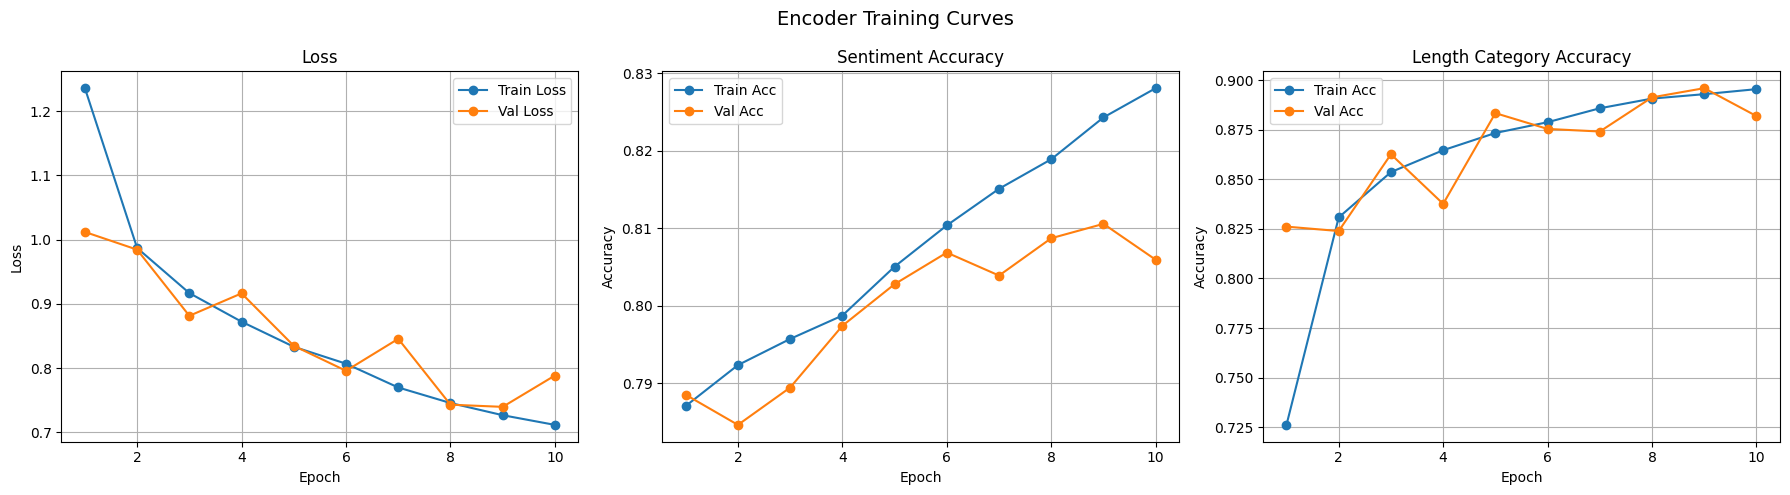

Learning curves saved.


In [30]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#loss
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   marker='o')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

#sentiment accuracy
axes[1].plot(epochs_range, history['train_acc_sentiment'], label='Train Acc', marker='o')
axes[1].plot(epochs_range, history['val_acc_sentiment'],   label='Val Acc',   marker='o')
axes[1].set_title('Sentiment Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)


axes[2].plot(epochs_range, history['train_acc_length'], label='Train Acc', marker='o')
axes[2].plot(epochs_range, history['val_acc_length'],   label='Val Acc',   marker='o')
axes[2].set_title('Length Category Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True)

plt.suptitle('Encoder Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig("results/encoder_learning_curves.png", dpi=150)
plt.show()
print("Learning curves saved.")

# Test Set Evaluation with Full Metrics

In [31]:
from sklearn.metrics import classification_report


model.load_state_dict(torch.load("models/encoder_best.pt", map_location=device))
model.eval()

all_sent_preds  = []
all_sent_labels = []
all_len_preds   = []
all_len_labels  = []

with torch.no_grad():
    for batch in test_loader:
        input_ids  = batch['input_ids'].to(device)
        sentiment  = batch['sentiment'].to(device)
        length_cat = batch['length_cat'].to(device)

        sentiment_logits, length_cat_logits, _ = model(input_ids)

        all_sent_preds.extend(sentiment_logits.argmax(dim=1).cpu().tolist())
        all_sent_labels.extend(sentiment.cpu().tolist())
        all_len_preds.extend(length_cat_logits.argmax(dim=1).cpu().tolist())
        all_len_labels.extend(length_cat.cpu().tolist())

print(" Sentiment Classification Report ")
print(classification_report(
    all_sent_labels, all_sent_preds,
    target_names=['Negative', 'Neutral', 'Positive']
))

print(" Length Category Classification Report ")
print(classification_report(
    all_len_labels, all_len_preds,
    target_names=['Short', 'Medium', 'Long']
))

 Sentiment Classification Report 
              precision    recall  f1-score   support

    Negative       0.60      0.46      0.52       589
     Neutral       0.36      0.10      0.16       550
    Positive       0.85      0.96      0.90      4261

    accuracy                           0.82      5400
   macro avg       0.60      0.51      0.53      5400
weighted avg       0.77      0.82      0.79      5400

 Length Category Classification Report 
              precision    recall  f1-score   support

       Short       0.94      0.89      0.91      1891
      Medium       0.84      0.87      0.85      1695
        Long       0.94      0.96      0.95      1814

    accuracy                           0.91      5400
   macro avg       0.90      0.90      0.90      5400
weighted avg       0.91      0.91      0.91      5400



# Save Embeddings

In [32]:
model.eval()
all_embeddings = []

with torch.no_grad():
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        _, _, cls_embedding = model(input_ids)
        all_embeddings.append(cls_embedding.cpu())

all_embeddings = torch.cat(all_embeddings, dim=0)   # shape: (train_size, d_model)

torch.save(all_embeddings, "results/train_embeddings.pt")
print(f"Training embeddings saved: {all_embeddings.shape}")

Training embeddings saved: torch.Size([25200, 128])


# **Part B - Retrieval Module**

In [33]:
import torch
import torch.nn.functional as F
import pickle
import numpy as np


train_embeddings = torch.load("results/train_embeddings.pt", map_location='cpu')
print(f"Loaded training embeddings: {train_embeddings.shape}")


#normalize embeddings for cosine similarity
train_embeddings_norm = F.normalize(train_embeddings, p=2, dim=1)
print("Embeddings normalized.")

Loaded training embeddings: torch.Size([25200, 128])
Embeddings normalized.


# Retrieval function

In [34]:
def retrieve_top_k(query_embedding, train_embeddings_norm, k=5):


    query_norm = F.normalize(query_embedding.unsqueeze(0), p=2, dim=1)  # (1, d_model)

    similarities = torch.matmul(query_norm, train_embeddings_norm.T).squeeze(0)  # (train_size,)


    top_k_scores, top_k_indices = torch.topk(similarities, k=k)

    return top_k_indices.tolist(), top_k_scores.tolist()

# Build query embeddings for test set

In [35]:
model.eval()
test_embeddings = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        _, _, cls_embedding = model(input_ids)
        test_embeddings.append(cls_embedding.cpu())

test_embeddings = torch.cat(test_embeddings, dim=0)   # (test_size, 128)
test_embeddings_norm = F.normalize(test_embeddings, p=2, dim=1)

torch.save(test_embeddings, "results/test_embeddings.pt")
print(f"Test embeddings saved: {test_embeddings.shape}")

Test embeddings saved: torch.Size([5400, 128])


# Retrieval quality analysis

In [36]:
K = 3


print(f"=== Retrieval Quality Analysis (k={K}) ===\n")

for i in range(5):
    #query review
    query_text      = test_df.iloc[i]['reviewText']
    query_sentiment = label_names[test_df.iloc[i]['sentiment']]
    query_embedding = test_embeddings[i]


    top_k_indices, top_k_scores = retrieve_top_k(query_embedding, train_embeddings_norm, k=K)

    print(f"--- Query {i+1} ---")
    print(f"Sentiment : {query_sentiment}")
    print(f"Review    : {query_text[:200]}")
    print(f"\nRetrieved Results:")

    for rank, (idx, score) in enumerate(zip(top_k_indices, top_k_scores)):
        retrieved_text      = train_df.iloc[idx]['reviewText']
        retrieved_sentiment = label_names[train_df.iloc[idx]['sentiment']]
        print(f"  Rank {rank+1} (score={score:.4f}) [{retrieved_sentiment}]: {retrieved_text[:150]}")

    print()

=== Retrieval Quality Analysis (k=3) ===

--- Query 1 ---
Sentiment : Neutral
Review    : I struggled trying to get these to stay in my ears, whereas they fit my wife's ears snugly. It's really frustrating since the sound quality is very good. I tried the variety of different buds that com

Retrieved Results:
  Rank 1 (score=0.9861) [Positive]: I love this foundation powder. It is *truly* very pale, verging on goth-gitl white, which is exactly what I need.  It has no orange or yellowness to i
  Rank 2 (score=0.9828) [Positive]: There are many different items out there like this but I have found this item to be one of the best. This is a repeat for me and will continue to purc
  Rank 3 (score=0.9814) [Positive]: This case is great. It was rather difficult to get on my phone, but once it was on it is great. It makes the phone seem much larger than it originally

--- Query 2 ---
Sentiment : Positive
Review    : The Dyson DC65 Animal Complete Vacuum Cleaner is an ultra huge upgrade from my

# Effect of k on retrieval

In [37]:
print(" Effect of k on Retrieval \n")

query_embedding = test_embeddings[0]
query_text = test_df.iloc[0]['reviewText']
print(f"Query: {query_text[:200]}\n")

for k in [1, 3, 5, 10]:
    top_k_indices, top_k_scores = retrieve_top_k(query_embedding, train_embeddings_norm, k=k)

    query_sent = test_df.iloc[0]['sentiment']
    matches = sum(1 for idx in top_k_indices if train_df.iloc[idx]['sentiment'] == query_sent)
    match_rate = matches / k

    print(f"k={k:2d} | Avg Score: {np.mean(top_k_scores):.4f} | "
          f"Sentiment Match Rate: {match_rate:.2f} ({matches}/{k})")

 Effect of k on Retrieval 

Query: I struggled trying to get these to stay in my ears, whereas they fit my wife's ears snugly. It's really frustrating since the sound quality is very good. I tried the variety of different buds that com

k= 1 | Avg Score: 0.9861 | Sentiment Match Rate: 0.00 (0/1)
k= 3 | Avg Score: 0.9834 | Sentiment Match Rate: 0.00 (0/3)
k= 5 | Avg Score: 0.9820 | Sentiment Match Rate: 0.00 (0/5)
k=10 | Avg Score: 0.9790 | Sentiment Match Rate: 0.00 (0/10)


# Save retrieval metadata

In [38]:
torch.save(train_embeddings_norm, "results/train_embeddings_norm.pt")
torch.save(test_embeddings_norm,  "results/test_embeddings_norm.pt")


retrieval_config = {'K': K}
with open("models/retrieval_config.pkl", "wb") as f:
    pickle.dump(retrieval_config, f)

print(f"Retrieval config saved: k={K}")
print("Normalized embeddings saved.")

Retrieval config saved: k=3
Normalized embeddings saved.


# **Part C -  Decoder Model for Explanation Generation**

In [39]:
from collections import Counter


STOPWORDS = set([
    'i', 'me', 'my', 'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on',
    'at', 'to', 'for', 'of', 'with', 'it', 'is', 'was', 'are', 'be',
    'this', 'that', 'have', 'has', 'had', 'not', 'so', 'do', 'did',
    'as', 'if', 'by', 'from', 'they', 'we', 'you', 'he', 'she', 'its',
    'been', 'would', 'could', 'should', 'will', 'just', 'very', 'also',
    'about', 'up', 'out', 'what', 'which', 'there', 'their', 'them',
    'then', 'than', 'when', 'all', 'one', 'get', 'got', 'can', 'no'
])

sentiment_words = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
length_words    = {0: 'short',    1: 'medium',  2: 'long'}

def extract_keywords(tokens, n=3):
    filtered = [t for t in tokens if t not in STOPWORDS and len(t) > 3]
    if not filtered:
        return ['product']
    counts = Counter(filtered)
    return [word for word, _ in counts.most_common(n)]

def build_explanation(row):
    sentiment_label = sentiment_words[row['sentiment']]
    length_label    = length_words[row['length_cat']]


    tokens = row['tokens']
    if isinstance(tokens, str):
        tokens = ast.literal_eval(tokens)

    keywords = extract_keywords(tokens, n=3)
    keyword_str = ' '.join(keywords)

    explanation = (
        f"this review is {sentiment_label.lower()} "
        f"the reviewer mentions {keyword_str} "
        f"it is a {length_label} review suggesting strong sentiment"
    )
    return explanation


train_df['explanation'] = train_df.apply(build_explanation, axis=1)
val_df['explanation']   = val_df.apply(build_explanation, axis=1)
test_df['explanation']  = test_df.apply(build_explanation, axis=1)

print("Sample explanations:")
for i in range(3):
    print(f"  {i+1}: {train_df['explanation'].iloc[i]}")

Sample explanations:
  1: this review is positive the reviewer mentions hair hairs hands it is a medium review suggesting strong sentiment
  2: this review is positive the reviewer mentions skin brush clairsonic it is a long review suggesting strong sentiment
  3: this review is negative the reviewer mentions product ends waste it is a short review suggesting strong sentiment


# Tokenize and encode explanations

In [40]:
DECODER_MAX_LEN = 32   # max output sequence length

def encode_explanation(explanation, word2idx, max_len):
    tokens = explanation.split()
    tokens = tokens[:max_len - 2]

    indices = [word2idx.get(t, UNK_IDX) for t in tokens]

    input_seq  = [SOS_IDX] + indices                          # decoder input
    target_seq = indices   + [EOS_IDX]                        # decoder target


    pad_len = max_len - len(input_seq)
    input_seq  = input_seq  + [PAD_IDX] * pad_len
    target_seq = target_seq + [PAD_IDX] * pad_len

    return input_seq, target_seq


def apply_encoding(df):
    inputs, targets = [], []
    for exp in df['explanation']:
        inp, tgt = encode_explanation(exp, word2idx, DECODER_MAX_LEN)
        inputs.append(inp)
        targets.append(tgt)
    df = df.copy()
    df['dec_input']  = inputs
    df['dec_target'] = targets
    return df

train_df = apply_encoding(train_df)
val_df   = apply_encoding(val_df)
test_df  = apply_encoding(test_df)

print("Sample decoder input  :", train_df['dec_input'].iloc[0])
print("Sample decoder target :", train_df['dec_target'].iloc[0])

Sample decoder input  : [2, 16504, 13485, 8443, 12118, 16402, 13487, 9873, 7214, 7231, 7282, 8463, 8443, 4, 9823, 13485, 15834, 15692, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Sample decoder target : [16504, 13485, 8443, 12118, 16402, 13487, 9873, 7214, 7231, 7282, 8463, 8443, 4, 9823, 13485, 15834, 15692, 1, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


# Decoder Dataset and DataLoader

In [41]:
class DecoderDataset(Dataset):
    def __init__(self, df, embeddings):
        def parse(x):
            if isinstance(x, list):
                return x
            return ast.literal_eval(x)

        self.encoder_input = df['input_ids'].apply(parse).tolist()
        self.dec_input     = df['dec_input'].tolist()
        self.dec_target    = df['dec_target'].tolist()
        self.sentiments    = df['sentiment'].tolist()
        self.length_cats   = df['length_cat'].tolist()
        self.embeddings    = embeddings

    def __len__(self):
        return len(self.dec_input)

    def __getitem__(self, idx):
        return {
            'encoder_input': torch.tensor(self.encoder_input[idx], dtype=torch.long),
            'dec_input':     torch.tensor(self.dec_input[idx],     dtype=torch.long),
            'dec_target':    torch.tensor(self.dec_target[idx],    dtype=torch.long),
            'sentiment':     torch.tensor(self.sentiments[idx],    dtype=torch.long),
            'length_cat':    torch.tensor(self.length_cats[idx],   dtype=torch.long),
            'cls_embedding': self.embeddings[idx]
        }


train_embeddings = torch.load("results/train_embeddings.pt", map_location='cpu')
test_embeddings  = torch.load("results/test_embeddings.pt",  map_location='cpu')


model.eval()
val_embeddings = []
with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(device)
        _, _, cls_emb = model(input_ids)
        val_embeddings.append(cls_emb.cpu())
val_embeddings = torch.cat(val_embeddings, dim=0)


train_dec_dataset = DecoderDataset(train_df, train_embeddings)
val_dec_dataset   = DecoderDataset(val_df,   val_embeddings)
test_dec_dataset  = DecoderDataset(test_df,  test_embeddings)

DECODER_BATCH_SIZE = 64

train_dec_loader = DataLoader(train_dec_dataset, batch_size=DECODER_BATCH_SIZE, shuffle=True)
val_dec_loader   = DataLoader(val_dec_dataset,   batch_size=DECODER_BATCH_SIZE, shuffle=False)
test_dec_loader  = DataLoader(test_dec_dataset,  batch_size=DECODER_BATCH_SIZE, shuffle=False)

print(f"Train dec batches : {len(train_dec_loader)}")
print(f"Val dec batches   : {len(val_dec_loader)}")
print(f"Test dec batches  : {len(test_dec_loader)}")

Train dec batches : 394
Val dec batches   : 85
Test dec batches  : 85


# Causal Mask

In [42]:
def make_causal_mask(seq_len, device):
    mask = torch.tril(torch.ones(seq_len, seq_len, device=device))
    return mask   # 1 = allowed, 0 = masked

#  Decoder Block

In [43]:
class DecoderBlock(nn.Module):

    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attention = MultiHeadAttention(d_model, num_heads, dropout)
        self.ff             = FeedForward(d_model, d_ff, dropout)
        self.norm1          = nn.LayerNorm(d_model)
        self.norm2          = nn.LayerNorm(d_model)
        self.dropout        = nn.Dropout(dropout)

    def forward(self, x, causal_mask=None):
        #masked self attention + residual
        attn_out, _ = self.self_attention(x, x, x, causal_mask)
        x = self.norm1(x + self.dropout(attn_out))

        #feed forward + residual
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))

        return x

# Full Decoder Model

In [44]:
class DecoderTransformer(nn.Module):

    def __init__(self, vocab_size, d_model, num_heads, num_layers,
                 d_ff, max_seq_len, dropout, pad_idx):
        super().__init__()

        self.d_model   = d_model
        self.pad_idx   = pad_idx

        #token embeddings + pos encoding
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc   = PositionalEncoding(d_model, max_seq_len + 4, dropout)


        self.cls_proj  = nn.Linear(d_model, d_model)

        self.sentiment_emb  = nn.Embedding(3, d_model)
        self.length_cat_emb = nn.Embedding(3, d_model)

        #decoder blocks
        self.decoder_blocks = nn.ModuleList([
            DecoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(d_model)


        self.output_proj = nn.Linear(d_model, vocab_size)

    def forward(self, dec_input, cls_embedding, sentiment, length_cat,
                retrieved_embeddings=None):

        batch_size  = dec_input.size(0)
        dec_seq_len = dec_input.size(1)

        #token embeddings
        tok_emb = self.embedding(dec_input)             # (batch, dec_seq_len, d_model)
        tok_emb = self.pos_enc(tok_emb)

        cls_vec = self.cls_proj(cls_embedding).unsqueeze(1)

        sent_vec = self.sentiment_emb(sentiment).unsqueeze(1)
        len_vec  = self.length_cat_emb(length_cat).unsqueeze(1)


        if retrieved_embeddings is not None:
            x = torch.cat([cls_vec, sent_vec, len_vec,
                           retrieved_embeddings, tok_emb], dim=1)
        else:
            x = torch.cat([cls_vec, sent_vec, len_vec, tok_emb], dim=1)

        full_seq_len = x.size(1)


        causal_mask = make_causal_mask(full_seq_len, x.device)

        #pass through decoder blocks
        for block in self.decoder_blocks:
            x = block(x, causal_mask)

        x = self.norm(x)

        num_prepended = 3 if retrieved_embeddings is None else 3 + retrieved_embeddings.size(1)
        token_out = x[:, num_prepended:, :]              # (batch, dec_seq_len, d_model)

        logits = self.output_proj(token_out)             # (batch, dec_seq_len, vocab_size)
        return logits

# Init decoder model

In [45]:
DEC_D_MODEL    = 128
DEC_NUM_HEADS  = 4
DEC_NUM_LAYERS = 2
DEC_D_FF       = 256
DEC_DROPOUT    = 0.1
DEC_LR         = 1e-3
DEC_EPOCHS     = 10

decoder = DecoderTransformer(
    vocab_size  = VOCAB_SIZE,
    d_model     = DEC_D_MODEL,
    num_heads   = DEC_NUM_HEADS,
    num_layers  = DEC_NUM_LAYERS,
    d_ff        = DEC_D_FF,
    max_seq_len = DECODER_MAX_LEN,
    dropout     = DEC_DROPOUT,
    pad_idx     = PAD_IDX
).to(device)


criterion_lm = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

dec_optimizer = torch.optim.Adam(decoder.parameters(), lr=DEC_LR)

total_params = sum(p.numel() for p in decoder.parameters() if p.requires_grad)
print(f"Decoder trainable parameters: {total_params:,}")

Decoder trainable parameters: 5,049,332


In [46]:
def get_retrieved_embeddings(cls_embeddings_batch, train_embeddings_norm, train_embeddings, k=3):
    batch_size = cls_embeddings_batch.size(0)
    retrieved  = []

    for i in range(batch_size):
        query = cls_embeddings_batch[i]
        top_k_indices, _ = retrieve_top_k(query, train_embeddings_norm, k=k)
        #stack retrieved embeddings: (k, d_model)
        ret_embs = torch.stack([train_embeddings[idx] for idx in top_k_indices], dim=0)
        retrieved.append(ret_embs)

    return torch.stack(retrieved, dim=0)   # (batch, k, d_model)

# Decoder Training and Validation Functions

In [47]:
train_embeddings_norm_cpu = torch.load("results/train_embeddings_norm.pt", map_location='cpu')
train_embeddings_cpu      = torch.load("results/train_embeddings.pt",      map_location='cpu')

def train_decoder_epoch(decoder, loader, optimizer, device, use_retrieval=True):
    decoder.train()
    total_loss = 0

    for batch in loader:
        dec_input    = batch['dec_input'].to(device)
        dec_target   = batch['dec_target'].to(device)
        sentiment    = batch['sentiment'].to(device)
        length_cat   = batch['length_cat'].to(device)
        cls_emb      = batch['cls_embedding'].to(device)

        optimizer.zero_grad()

        if use_retrieval:
            ret_embs = get_retrieved_embeddings(
                batch['cls_embedding'],
                train_embeddings_norm_cpu,
                train_embeddings_cpu,
                k=K
            ).to(device)
        else:
            ret_embs = None

        logits = decoder(dec_input, cls_emb, sentiment, length_cat, ret_embs)


        #flatten for cross entropy
        loss = criterion_lm(
            logits.view(-1, VOCAB_SIZE),
            dec_target.view(-1)
        )

        loss.backward()
        torch.nn.utils.clip_grad_norm_(decoder.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_decoder(decoder, loader, device, use_retrieval=True):
    decoder.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            dec_input  = batch['dec_input'].to(device)
            dec_target = batch['dec_target'].to(device)
            sentiment  = batch['sentiment'].to(device)
            length_cat = batch['length_cat'].to(device)
            cls_emb    = batch['cls_embedding'].to(device)

            if use_retrieval:
                ret_embs = get_retrieved_embeddings(
                    batch['cls_embedding'],
                    train_embeddings_norm_cpu,
                    train_embeddings_cpu,
                    k=K
                ).to(device)
            else:
                ret_embs = None

            logits = decoder(dec_input, cls_emb, sentiment, length_cat, ret_embs)

            loss = criterion_lm(
                logits.view(-1, VOCAB_SIZE),
                dec_target.view(-1)
            )
            total_loss += loss.item()

    avg_loss   = total_loss / len(loader)
    perplexity = math.exp(avg_loss)
    return avg_loss, perplexity

# Decoder Training Loop

In [48]:
dec_history = {
    'train_loss': [], 'val_loss': [], 'val_perplexity': []
}

best_dec_val_loss = float('inf')

print(f"Training decoder for {DEC_EPOCHS} epochs...\n")

for epoch in range(1, DEC_EPOCHS + 1):
    train_loss          = train_decoder_epoch(decoder, train_dec_loader, dec_optimizer, device)
    val_loss, val_ppl   = evaluate_decoder(decoder, val_dec_loader, device)

    dec_history['train_loss'].append(train_loss)
    dec_history['val_loss'].append(val_loss)
    dec_history['val_perplexity'].append(val_ppl)

    print(f"Epoch {epoch:02d}/{DEC_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Perplexity: {val_ppl:.4f}")

    if val_loss < best_dec_val_loss:
        best_dec_val_loss = val_loss
        torch.save(decoder.state_dict(), "models/decoder_best.pt")
        print(f"  --> Best decoder saved at epoch {epoch}")

print("\nDecoder training complete.")

Training decoder for 10 epochs...

Epoch 01/10 | Train Loss: 1.4502 | Val Loss: 1.0790 | Val Perplexity: 2.9417
  --> Best decoder saved at epoch 1
Epoch 02/10 | Train Loss: 1.0591 | Val Loss: 1.0663 | Val Perplexity: 2.9045
  --> Best decoder saved at epoch 2
Epoch 03/10 | Train Loss: 1.0237 | Val Loss: 1.0643 | Val Perplexity: 2.8988
  --> Best decoder saved at epoch 3
Epoch 04/10 | Train Loss: 0.9827 | Val Loss: 1.0674 | Val Perplexity: 2.9078
Epoch 05/10 | Train Loss: 0.9446 | Val Loss: 1.0752 | Val Perplexity: 2.9305
Epoch 06/10 | Train Loss: 0.9108 | Val Loss: 1.0876 | Val Perplexity: 2.9671
Epoch 07/10 | Train Loss: 0.8820 | Val Loss: 1.1022 | Val Perplexity: 3.0107
Epoch 08/10 | Train Loss: 0.8584 | Val Loss: 1.1169 | Val Perplexity: 3.0554
Epoch 09/10 | Train Loss: 0.8396 | Val Loss: 1.1311 | Val Perplexity: 3.0989
Epoch 10/10 | Train Loss: 0.8230 | Val Loss: 1.1468 | Val Perplexity: 3.1482

Decoder training complete.


#  Decoder Learning Curves

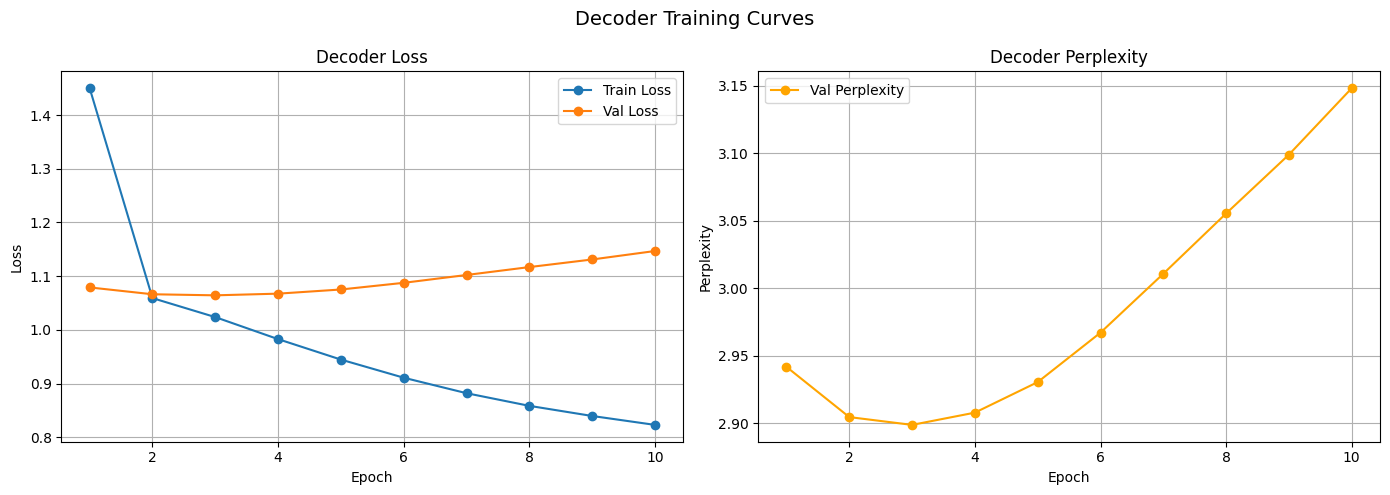

Decoder learning curves saved.


In [49]:
epochs_range = range(1, DEC_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, dec_history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(epochs_range, dec_history['val_loss'],   label='Val Loss',   marker='o')
axes[0].set_title('Decoder Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, dec_history['val_perplexity'], label='Val Perplexity',
             marker='o', color='orange')
axes[1].set_title('Decoder Perplexity')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Decoder Training Curves', fontsize=14)
plt.tight_layout()
plt.savefig("results/decoder_learning_curves.png", dpi=150)
plt.show()
print("Decoder learning curves saved.")

# Test Set Perplexity

In [50]:
decoder.load_state_dict(torch.load("models/decoder_best.pt", map_location=device))

test_loss, test_ppl = evaluate_decoder(decoder, test_dec_loader, device, use_retrieval=True)

print(f"=== Test Set Evaluation ===")
print(f"Test Loss       : {test_loss:.4f}")
print(f"Test Perplexity : {test_ppl:.4f}")

=== Test Set Evaluation ===
Test Loss       : 1.0600
Test Perplexity : 2.8864


# Autoregressive Generation

In [51]:
def generate_explanation(decoder, model, encoder_input, sentiment_label,
                         length_cat_label, train_embeddings_norm,
                         train_embeddings, word2idx, idx2word,
                         max_gen_len=32, k=3, device='cpu',
                         use_retrieval=True):

    decoder.eval()
    model.eval()

    with torch.no_grad():
        #get cls embedding from encoder
        enc_input_tensor = torch.tensor(encoder_input, dtype=torch.long).unsqueeze(0).to(device)
        _, _, cls_emb = model(enc_input_tensor)            # (1, d_model)

        #retrieve context
        if use_retrieval:
            ret_embs = get_retrieved_embeddings(
                cls_emb.cpu(), train_embeddings_norm, train_embeddings, k=k
            ).to(device)                                   # (1, k, d_model)
        else:
            ret_embs = None

        sent_tensor = torch.tensor([sentiment_label], dtype=torch.long).to(device)
        len_tensor  = torch.tensor([length_cat_label], dtype=torch.long).to(device)

        #start with sos
        generated = [SOS_IDX]

        for _ in range(max_gen_len):
            dec_input = torch.tensor([generated], dtype=torch.long).to(device)

            logits = decoder(dec_input, cls_emb, sent_tensor, len_tensor, ret_embs)
            # logits: (1, current_len, vocab_size)


            next_token_logits = logits[0, -1, :]
            next_token = next_token_logits.argmax(dim=-1).item()

            if next_token == EOS_IDX:
                break

            generated.append(next_token)

        words = [idx2word.get(idx, '<UNK>') for idx in generated[1:]]
        return ' '.join(words)

# Qualitative Evaluation

In [52]:
decoder.load_state_dict(torch.load("models/decoder_best.pt", map_location=device))

print(" Qualitative Evaluation\n")

for i in range(5):
    row = test_df.iloc[i]

    encoder_input   = row['input_ids'] if isinstance(row['input_ids'], list) \
                      else ast.literal_eval(row['input_ids'])
    sentiment_label = row['sentiment']
    length_cat_label= row['length_cat']
    reference       = row['explanation']
    review_text     = row['reviewText']

    generated = generate_explanation(
        decoder, model,
        encoder_input, sentiment_label, length_cat_label,
        train_embeddings_norm_cpu, train_embeddings_cpu,
        word2idx, idx2word,
        max_gen_len=32, k=K, device=device, use_retrieval=True
    )

    print(f"--- Example {i+1} ---")
    print(f"Review     : {review_text[:200]}")
    print(f"Sentiment  : {sentiment_words[sentiment_label]}")
    print(f"Length Cat : {length_words[length_cat_label]}")
    print(f"Reference  : {reference}")
    print(f"Generated  : {generated}")
    print()

 Qualitative Evaluation

--- Example 1 ---
Review     : I struggled trying to get these to stay in my ears, whereas they fit my wife's ears snugly. It's really frustrating since the sound quality is very good. I tried the variety of different buds that com
Sentiment  : Neutral
Length Cat : medium
Reference  : this review is neutral the reviewer mentions trying these ears it is a medium review suggesting strong sentiment
Generated  : this review is neutral the reviewer mentions case phone like it is a medium review suggesting strong <UNK>

--- Example 2 ---
Review     : The Dyson DC65 Animal Complete Vacuum Cleaner is an ultra huge upgrade from my old DC25 in terms of everything you can think of: suction, looks, functionality. It still operates on the same ball princ
Sentiment  : Positive
Length Cat : long
Reference  : this review is positive the reviewer mentions suction dyson more it is a long review suggesting strong sentiment
Generated  : this review is positive the reviewer mention

# RAG Ablation

In [53]:
print("Training baseline decoder (no retrieval)\n")

baseline_decoder = DecoderTransformer(
    vocab_size  = VOCAB_SIZE,
    d_model     = DEC_D_MODEL,
    num_heads   = DEC_NUM_HEADS,
    num_layers  = DEC_NUM_LAYERS,
    d_ff        = DEC_D_FF,
    max_seq_len = DECODER_MAX_LEN,
    dropout     = DEC_DROPOUT,
    pad_idx     = PAD_IDX
).to(device)

baseline_optimizer = torch.optim.Adam(baseline_decoder.parameters(), lr=DEC_LR)
best_baseline_loss = float('inf')

for epoch in range(1, DEC_EPOCHS + 1):
    train_loss = train_decoder_epoch(
        baseline_decoder, train_dec_loader, baseline_optimizer,
        device, use_retrieval=False
    )
    val_loss, val_ppl = evaluate_decoder(
        baseline_decoder, val_dec_loader, device, use_retrieval=False
    )

    print(f"Epoch {epoch:02d}/{DEC_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Perplexity: {val_ppl:.4f}")

    if val_loss < best_baseline_loss:
        best_baseline_loss = val_loss
        torch.save(baseline_decoder.state_dict(), "models/decoder_baseline.pt")

print("\nBaseline training complete.")

Training baseline decoder (no retrieval)

Epoch 01/10 | Train Loss: 1.4619 | Val Loss: 1.0762 | Val Perplexity: 2.9335
Epoch 02/10 | Train Loss: 1.0602 | Val Loss: 1.0663 | Val Perplexity: 2.9048
Epoch 03/10 | Train Loss: 1.0223 | Val Loss: 1.0636 | Val Perplexity: 2.8967
Epoch 04/10 | Train Loss: 0.9812 | Val Loss: 1.0655 | Val Perplexity: 2.9021
Epoch 05/10 | Train Loss: 0.9436 | Val Loss: 1.0735 | Val Perplexity: 2.9256
Epoch 06/10 | Train Loss: 0.9111 | Val Loss: 1.0866 | Val Perplexity: 2.9641
Epoch 07/10 | Train Loss: 0.8833 | Val Loss: 1.1008 | Val Perplexity: 3.0066
Epoch 08/10 | Train Loss: 0.8614 | Val Loss: 1.1121 | Val Perplexity: 3.0409
Epoch 09/10 | Train Loss: 0.8423 | Val Loss: 1.1234 | Val Perplexity: 3.0753
Epoch 10/10 | Train Loss: 0.8268 | Val Loss: 1.1351 | Val Perplexity: 3.1116

Baseline training complete.


# Ablation Results Table

In [54]:
decoder.load_state_dict(torch.load("models/decoder_best.pt",      map_location=device))
baseline_decoder.load_state_dict(torch.load("models/decoder_baseline.pt", map_location=device))


rag_loss,      rag_ppl      = evaluate_decoder(decoder,          test_dec_loader, device, use_retrieval=True)
baseline_loss, baseline_ppl = evaluate_decoder(baseline_decoder, test_dec_loader, device, use_retrieval=False)

print("=== RAG Ablation Study ===")
print(f"{'System':<25} {'Test Loss':>12} {'Perplexity':>12}")
print("-" * 50)
print(f"{'Full RAG (with retrieval)':<25} {rag_loss:>12.4f} {rag_ppl:>12.4f}")
print(f"{'Baseline (no retrieval)':<25} {baseline_loss:>12.4f} {baseline_ppl:>12.4f}")
print("-" * 50)
improvement = ((baseline_ppl - rag_ppl) / baseline_ppl) * 100
print(f"Perplexity improvement from RAG: {improvement:.2f}%")

=== RAG Ablation Study ===
System                       Test Loss   Perplexity
--------------------------------------------------
Full RAG (with retrieval)       1.0600       2.8864
Baseline (no retrieval)         1.0606       2.8881
--------------------------------------------------
Perplexity improvement from RAG: 0.06%


In [55]:
import json

results = {
    'encoder': {
        'test_sentiment_accuracy': float(sum(s == l for s, l in
            zip(all_sent_preds, all_sent_labels)) / len(all_sent_labels)),
        'test_length_accuracy': float(sum(s == l for s, l in
            zip(all_len_preds, all_len_labels)) / len(all_len_labels)),
    },
    'decoder_rag': {
        'test_loss': rag_loss,
        'test_perplexity': rag_ppl
    },
    'decoder_baseline': {
        'test_loss': baseline_loss,
        'test_perplexity': baseline_ppl
    },
    'ablation_improvement_pct': improvement
}

with open("results/final_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Final results saved to results/final_results.json")
print(json.dumps(results, indent=2))

Final results saved to results/final_results.json
{
  "encoder": {
    "test_sentiment_accuracy": 0.8175925925925925,
    "test_length_accuracy": 0.9055555555555556
  },
  "decoder_rag": {
    "test_loss": 1.060013015129987,
    "test_perplexity": 2.8864085560060415
  },
  "decoder_baseline": {
    "test_loss": 1.0605991510783925,
    "test_perplexity": 2.88810087973994
  },
  "ablation_improvement_pct": 0.05859642042874174
}
